In [1]:
%pip install networkx matplotlib numpy -q


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


# 🚀 Model 3: Scheduling Optimization Architecture
이 노트북은 OptaPlanner 기반의 **Model 3 (BAVET + Simulated Annealing + 공정성 및 연속근무 제약)** 의 전체적인 아키텍처와 작동 원리를 파이썬 코드로 시각화하여 설명합니다.

### 핵심 구성 요소
1. **BAVET Stream Engine**: 초고속 제약 조건(Constraints) 평가 엔진. 메모리를 적게 쓰면서 점수(Score)를 실시간으로 계산합니다.
2. **Simulated Annealing (담금질 기법)**: 지역 최적해(Local Optima)에 빠지는 것을 막기 위해, 초기에는 나쁜 스케줄도 확률적으로 수용하며 탐색 공간을 넓게 가져가고, 후반부(온도가 식음)에는 좋은 스케줄만 채택하여 점진적으로 수렴하는 휴리스틱 탐색 알고리즘입니다.


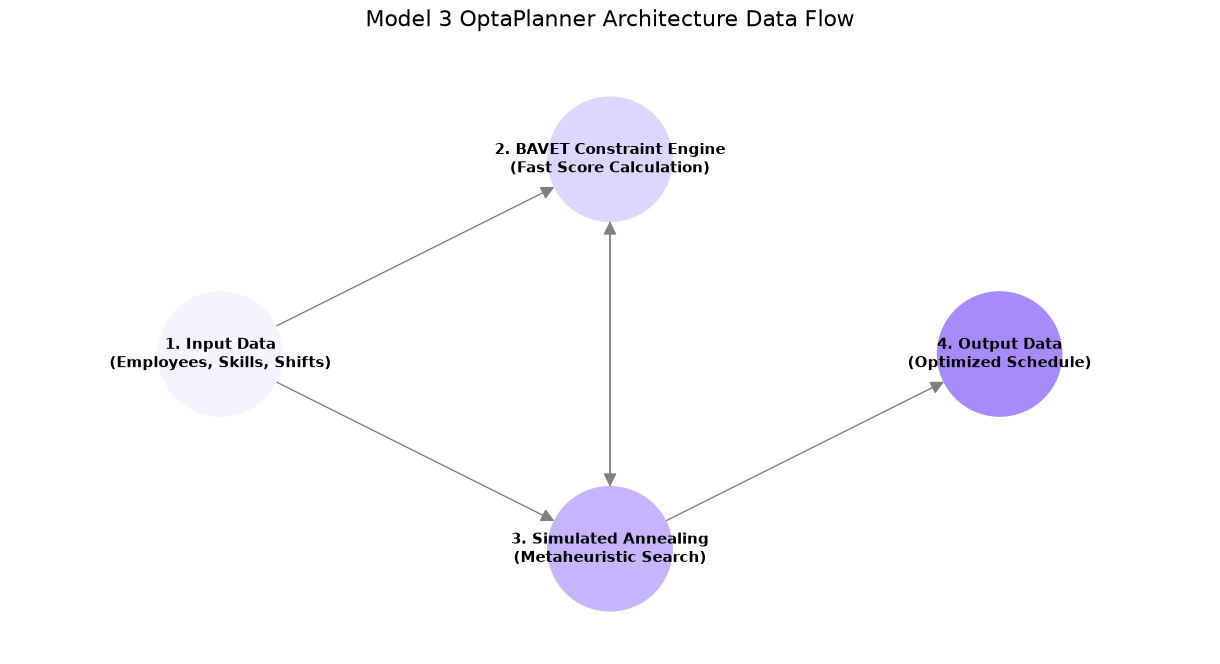

In [2]:
import networkx as nx
import matplotlib.pyplot as plt

# 아키텍처 다이어그램 생성
G = nx.DiGraph()

# 노드 정의
nodes = [
    ("1. Input Data\n(Employees, Skills, Shifts)", {"pos": (0, 2), "color": "#F5F3FF"}),
    ("2. BAVET Constraint Engine\n(Fast Score Calculation)", {"pos": (2, 3), "color": "#DDD6FE"}),
    ("3. Simulated Annealing\n(Metaheuristic Search)", {"pos": (2, 1), "color": "#C4B5FD"}),
    ("4. Output Data\n(Optimized Schedule)", {"pos": (4, 2), "color": "#A78BFA"}),
]

for node, attrs in nodes:
    G.add_node(node, pos=attrs["pos"], color=attrs["color"])

# 엣지 (데이터 흐름) 정의
edges = [
    (nodes[0][0], nodes[1][0]),
    (nodes[0][0], nodes[2][0]),
    (nodes[1][0], nodes[2][0]), # BAVET -> SA (점수 반환)
    (nodes[2][0], nodes[1][0]), # SA -> BAVET (새로운 스케줄 시도)
    (nodes[2][0], nodes[3][0]),
]
G.add_edges_from(edges)

# 그래프 그리기
pos = nx.get_node_attributes(G, 'pos')
colors = [nx.get_node_attributes(G, 'color')[node] for node in G.nodes()]

plt.figure(figsize=(12, 6))
nx.draw(G, pos, with_labels=True, node_color=colors, node_size=8000, 
        font_size=11, font_weight="bold", arrows=True, arrowsize=20, edge_color="gray")

plt.title("Model 3 OptaPlanner Architecture Data Flow", fontsize=16, pad=20)
plt.margins(0.2)
plt.axis("off")
plt.show()


### 🌡️ Simulated Annealing (담금질 기법) 시뮬레이션
Model 3이 어떻게 수만 가지의 스케줄 조합 중 가장 완벽한 해를 찾아내는지, **온도(Temperature) 하락에 따른 점수 수렴 과정**을 수학적으로 시뮬레이션 해봅니다.

* **수락 확률(Acceptance Probability)**: $P = e^{\frac{\Delta E}{T}}$
* 온도가 높을 때($T \to \infty$): $P \to 1$ (나쁜 스케줄도 수용하여 다양한 패턴 탐색)
* 온도가 낮을 때($T \to 0$): $P \to 0$ (오직 점수가 개선되는 스케줄만 수용)


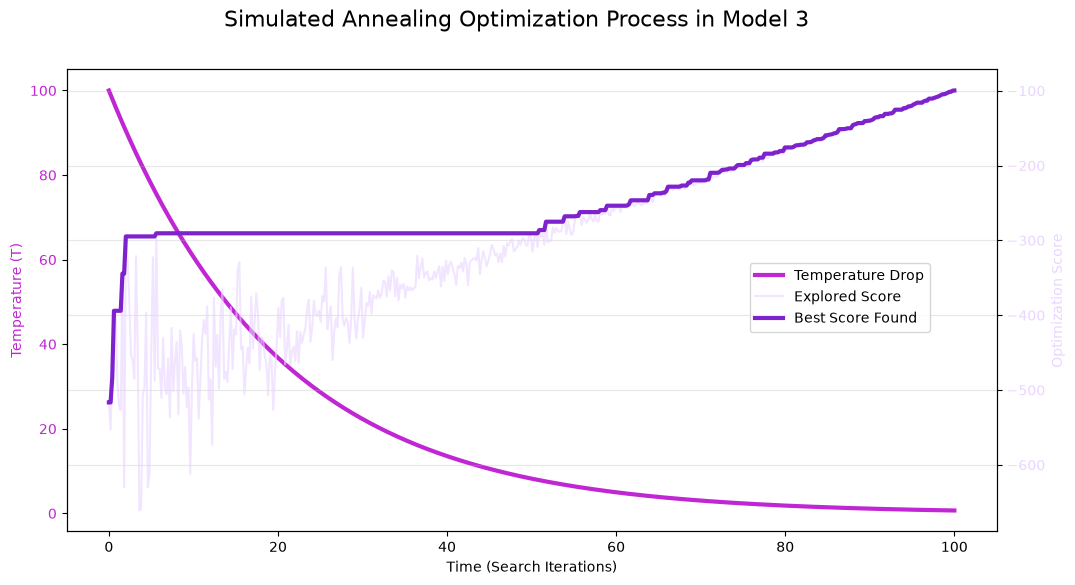

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# 파라미터 설정
time_steps = np.linspace(0, 100, 500)
initial_temperature = 100
cooling_rate = 0.05

# 온도 하락 곡선 (지수 감소)
temperature = initial_temperature * np.exp(-cooling_rate * time_steps)

# 탐색 과정의 가상 점수 (Score) 시뮬레이션
# 처음엔 변동폭이 크고 나쁜 점수도 허용하다가, 온도가 식을수록 점수가 좋아지며 수렴함
base_score = -500 + (time_steps * 4) # 시간이 지날수록 점수 상승 경향
noise = np.random.normal(0, temperature, len(time_steps)) # 온도에 비례하는 무작위 탐색(변동성)
scores = base_score + noise

# 시각화
fig, ax1 = plt.subplots(figsize=(12, 6))

color = '#C026D3'
ax1.set_xlabel('Time (Search Iterations)')
ax1.set_ylabel('Temperature (T)', color=color)
ax1.plot(time_steps, temperature, color=color, linewidth=3, label='Temperature Drop')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  
color = '#E9D5FF'
ax2.set_ylabel('Optimization Score', color=color)  
ax2.plot(time_steps, scores, color=color, alpha=0.6, label='Explored Score')
# 베스트 점수 궤적 추적
best_scores = np.maximum.accumulate(scores)
ax2.plot(time_steps, best_scores, color='#7E22CE', linewidth=3, label='Best Score Found')
ax2.tick_params(axis='y', labelcolor=color)

fig.suptitle("Simulated Annealing Optimization Process in Model 3", fontsize=16)
fig.legend(loc="center right", bbox_to_anchor=(0.85, 0.5))
plt.grid(True, alpha=0.3)
plt.show()


### ⚖️ Model 3 제약 조건 (Constraints) 아키텍처
Model 3에서 BAVET 엔진이 점수를 계산할 때 사용하는 **패널티 산정 기준**입니다. 
이 제약들이 조합되어 최종 `Score (0hard/0medium/-300soft)`가 결정됩니다.

1. **Hard Constraints (절대 어기면 안 되는 규칙)**
   - `ShiftOnRequest`: 특정 시간에 무조건 근무해야 하는 요청 준수
2. **Medium Constraints (가능한 지켜야 하는 규칙)**
   - `DayOffRequest` / `ShiftOffRequest`: 직원이 튜플로 요청한 휴가나 비번 반영
3. **Soft Constraints (스케줄의 퀄리티를 결정하는 규칙)**
   - `Fair Workload Distribution`: (직원 간 근무 횟수 편차)$^2$ 만큼 감점하여 공정성 극대화
   - `Max Consecutive Working Days`: 3일 이상 연속 근무 시 기하급수적 페널티 부과 (번아웃 방지)
